## Optimization Example Notebook
Here is an example of how to setup a simple optimization test using the gradients calculated using 
JAX's automatic differentiation capabilities. 

In this notebook we setup a forward function wrapper, loss function to optimize over, and a basic gradient desent optimization loop as a basic optimization example

In [17]:
from jcm.model import Model
from jcm.geometry import Geometry
from jcm.forcing import ForcingData, _fixed_ssts

# Load the terrain and forcing data (interpolated to the default model grid)
realistic_geometry = Geometry.from_file('jcm/data/bc/t30/clim/terrain.nc', target_resolution=31)
realistic_forcing = ForcingData.from_file('jcm/data/bc/t30/clim/forcing.nc', target_resolution=31)

In [18]:
import jax
import jax.numpy as jnp
from jcm.physics.speedy.speedy_physics import SpeedyPhysics
from jcm.physics.speedy.params import Parameters

import optax

In [21]:
def forward_model_wrapper(sst, jcm_model, realistic_forcing):
    forcing = realistic_forcing
    forcing.sea_surface_temperature = jnp.ones_like(forcing.sea_surface_temperature)*sst[jnp.newaxis,:,jnp.newaxis] 
    predictions = jcm_model.run(save_interval=12/24, total_time=10, forcing=forcing, output_averages=True)
    return predictions.physics.condensation.precls[-1]
   

def loss_function(theta, forward_model, y, args = ()): 
    '''
    Returns data-model misfit (i.e. loss function to optimize over)

    Args: 
        theta: parameters of interest (find the parameters that minimize the loss function)
        forward_model: forward run through model with output the same shape as y
        y: data to compare model to (must be 1D vector)
        args: additional forward model function inputs
    '''

    return 0.5*jnp.linalg.norm((y - forward_model(theta, *args)))**2

grad_loss_function = jax.grad(loss_function, argnums = 0)

In [5]:
true_forcing = realistic_forcing
model = Model(geometry=realistic_geometry)
true_forcing.sea_surface_temperature = _fixed_ssts((model.coords.horizontal))
predictions = model.run(save_interval=12/24, total_time=10, forcing=true_forcing, output_averages=True)

In [6]:
y = predictions.physics.condensation.precls[-1]

### Optimizing SSTs at each latitude

In [ ]:
solver = optax.adabelief(learning_rate=0.1)
theta = 290*jnp.ones(48) # initial guess
print('Objective function: ', loss_function(theta, forward_model_wrapper, y, args = (model, realistic_forcing)))
opt_state = solver.init(theta)
for _ in range(10):
    grad = grad_loss_function(theta, forward_model_wrapper, y, args = (model, realistic_forcing))
    updates, opt_state = solver.update(grad, opt_state, theta)
    theta = optax.apply_updates(theta, updates)
    print('Objective function: {:.2E}'.format(loss_function(theta, forward_model_wrapper, y, args = (model, realistic_forcing))))

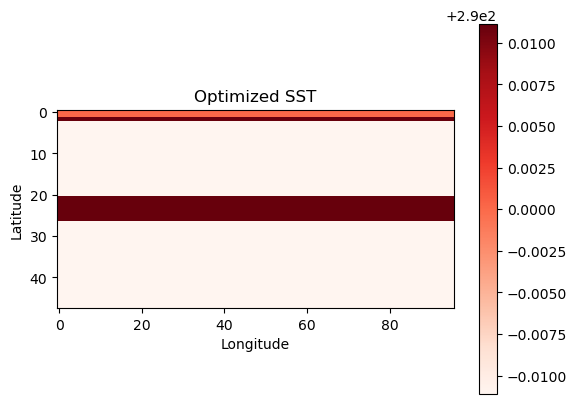

In [25]:
import matplotlib.pyplot as plt

plt.imshow((jnp.ones((96,48))*theta[jnp.newaxis, :]).T, cmap='Reds')
plt.title('Optimized SST')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.colorbar()



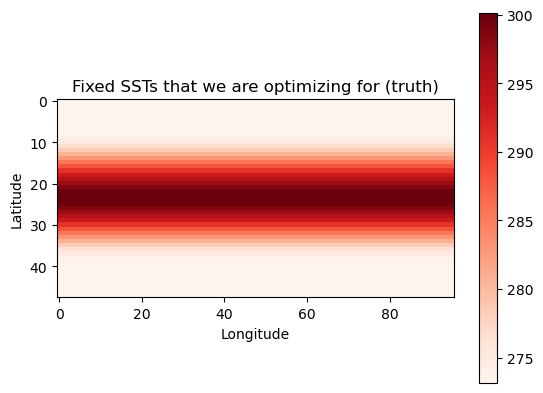

In [26]:
fixed = _fixed_ssts((model.coords.horizontal))

plt.imshow(fixed.T, cmap='Reds')
plt.title('Fixed SSTs that we are optimizing for (truth)')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.colorbar()

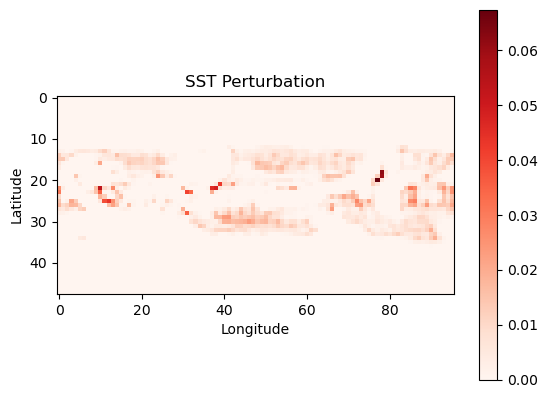

In [ ]:
# True precipitation at lst timestep
plt.imshow(predictions.physics.condensation.precls[-1].T, cmap='Reds')
plt.title('SST Perturbation')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.colorbar()